# Data Balancing Techniques

This notebook demonstrates various techniques for handling class imbalance in e-commerce sales prediction.

## Overview

Class imbalance is a common problem in binary classification where one class significantly outnumbers the other. This can lead to:
- Biased models that favor the majority class
- Poor minority class recall
- Misleading accuracy metrics
- Bimodal probability distributions

## Techniques Covered:

1. **SMOTE** (Synthetic Minority Over-sampling Technique)
2. **Borderline-SMOTE** - Focuses on borderline instances
3. **ADASYN** (Adaptive Synthetic Sampling)
4. **SMOTE-ENN** - Combines over and under-sampling
5. **SMOTE-Tomek** - Removes Tomek links
6. **Class Weight Balancing**
7. **Threshold Optimization**

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

# Imbalanced-learn library
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours, TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    precision_recall_curve, roc_curve
)
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")
print("imbalanced-learn version available for advanced sampling techniques")

Libraries loaded successfully!
imbalanced-learn version available for advanced sampling techniques


## Load and Analyze Data

In [2]:
# Load data
print("Loading dataset...")

# Try different data paths
data_paths = [
    '../data/processed/ecommerce_sales_engineered.csv',
    '../data/processed/ecommerce_sales_featured.csv'
]

for path in data_paths:
    if Path(path).exists():
        data = pd.read_csv(path)
        print(f"Loaded data from: {path}")
        break
else:
    print("Creating sample imbalanced dataset...")
    # Create a sample imbalanced dataset
    np.random.seed(42)
    n_samples = 1000
    n_features = 20
    
    # Create imbalanced classes (80% class 0, 20% class 1)
    X = np.random.randn(n_samples, n_features)
    y = np.random.choice([0, 1], size=n_samples, p=[0.8, 0.2])
    
    feature_names = [f'feature_{i}' for i in range(n_features)]
    data = pd.DataFrame(X, columns=feature_names)
    data['success'] = y

# Prepare features and target
if 'success' in data.columns:
    feature_cols = [col for col in data.columns if col not in ['success', 'product_id', 'product_name', 'category']]
    feature_cols = data[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    X = data[feature_cols].values
    y = data['success'].values
else:
    # Use last column as target
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values

print(f"\nDataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")

Loading dataset...
Loaded data from: ../data/processed/ecommerce_sales_engineered.csv

Dataset shape: (1000, 113)
Number of features: 113
Number of samples: 1000



Original Class Distribution:
----------------------------------------
Class 0:   500 samples ( 50.0%)
Class 1:   500 samples ( 50.0%)

Imbalance ratio: 1.00:1
✅ Classes are relatively balanced


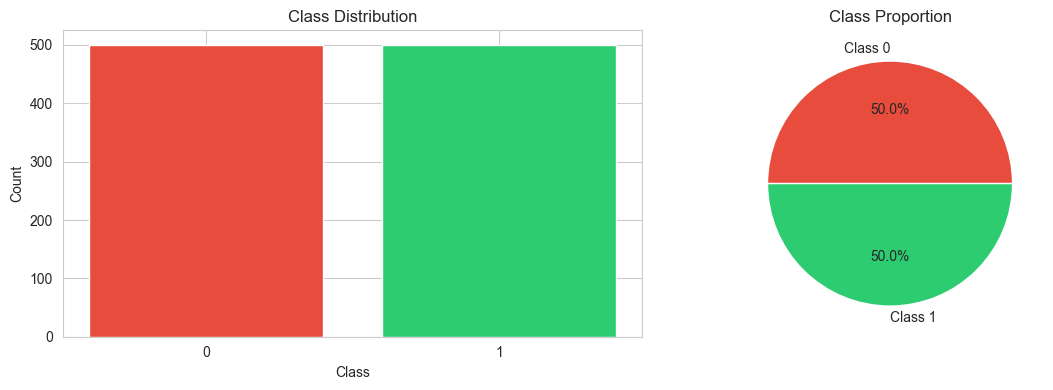

In [3]:
# Analyze class distribution
def analyze_class_distribution(y, title="Class Distribution"):
    """Analyze and visualize class distribution"""
    unique, counts = np.unique(y, return_counts=True)
    
    print(f"\n{title}:")
    print("-" * 40)
    
    for cls, count in zip(unique, counts):
        percentage = (count / len(y)) * 100
        print(f"Class {cls}: {count:5d} samples ({percentage:5.1f}%)")
    
    # Calculate imbalance ratio
    if len(counts) == 2:
        imbalance_ratio = counts[0] / counts[1] if counts[1] > 0 else np.inf
        print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
        
        if imbalance_ratio > 3:
            print("⚠️ Significant class imbalance detected!")
        elif imbalance_ratio > 1.5:
            print("⚠️ Moderate class imbalance detected")
        else:
            print("✅ Classes are relatively balanced")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Bar plot
    ax1.bar(unique, counts, color=['#e74c3c', '#2ecc71'])
    ax1.set_xlabel('Class')
    ax1.set_ylabel('Count')
    ax1.set_title('Class Distribution')
    ax1.set_xticks(unique)
    
    # Pie chart
    ax2.pie(counts, labels=[f'Class {c}' for c in unique], 
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'])
    ax2.set_title('Class Proportion')
    
    plt.tight_layout()
    plt.show()
    
    return dict(zip(unique, counts))

# Analyze original distribution
original_dist = analyze_class_distribution(y, "Original Class Distribution")


Train/Test Split:
Training samples: 800
Test samples: 200

Training Set Distribution:
----------------------------------------
Class 0:   400 samples ( 50.0%)
Class 1:   400 samples ( 50.0%)

Imbalance ratio: 1.00:1
✅ Classes are relatively balanced


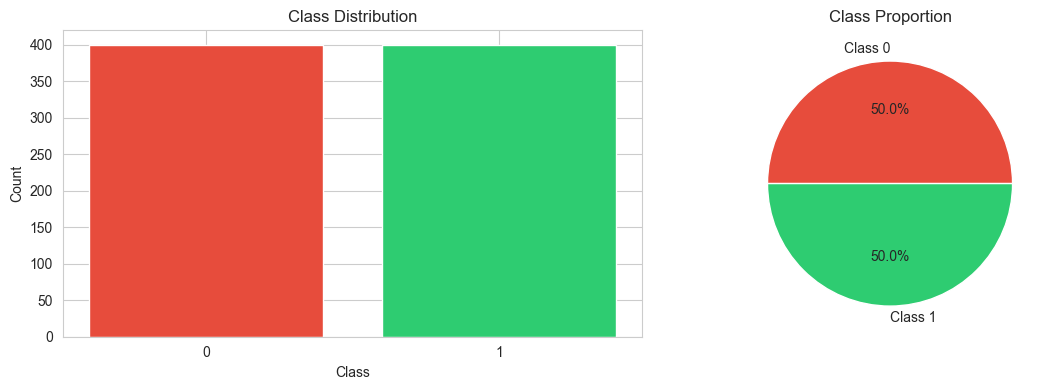

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain/Test Split:")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Analyze training set distribution
train_dist = analyze_class_distribution(y_train, "Training Set Distribution")

## Baseline Model (No Balancing)

In [5]:
def train_and_evaluate(X_train, y_train, X_test, y_test, model_name="Model"):
    """Train and evaluate a model"""
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    model = xgb.XGBClassifier(
        max_depth=4,
        n_estimators=100,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_proba)
    }
    
    # Probability distribution
    extreme_count = np.sum((y_proba < 0.1) | (y_proba > 0.9))
    middle_count = np.sum((y_proba >= 0.2) & (y_proba <= 0.8))
    
    print(f"\n{model_name} Performance:")
    print("-" * 40)
    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1-Score:  {metrics['f1']:.4f}")
    print(f"AUC-ROC:   {metrics['auc']:.4f}")
    print(f"\nProbability Distribution:")
    print(f"Extreme (<0.1 or >0.9): {extreme_count/len(y_proba)*100:.1f}%")
    print(f"Middle (0.2-0.8):       {middle_count/len(y_proba)*100:.1f}%")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    return metrics, y_proba, cm

# Train baseline model
baseline_metrics, baseline_proba, baseline_cm = train_and_evaluate(
    X_train, y_train, X_test, y_test, "Baseline (No Balancing)"
)


Baseline (No Balancing) Performance:
----------------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
AUC-ROC:   1.0000

Probability Distribution:
Extreme (<0.1 or >0.9): 100.0%
Middle (0.2-0.8):       0.0%


## Method 1: SMOTE (Synthetic Minority Over-sampling)

SMOTE - Synthetic Minority Over-sampling Technique

Original training set size: 800
SMOTE resampled set size: 800

SMOTE Resampled Distribution:
----------------------------------------
Class 0:   400 samples ( 50.0%)
Class 1:   400 samples ( 50.0%)

Imbalance ratio: 1.00:1
✅ Classes are relatively balanced


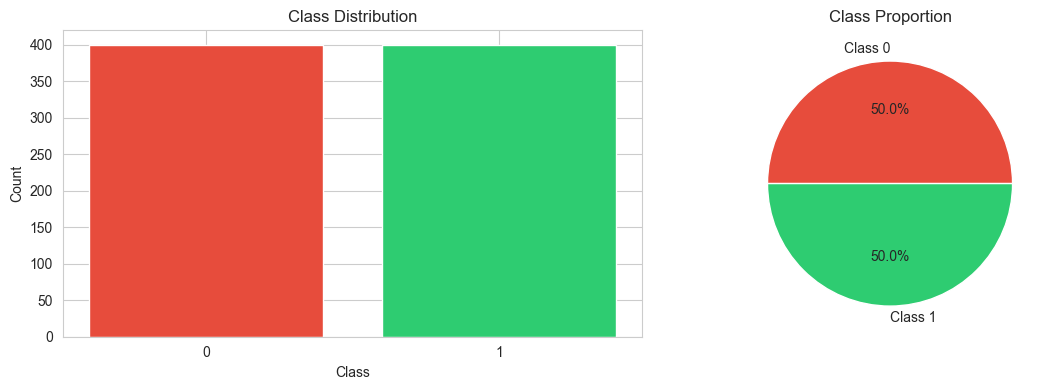


SMOTE Model Performance:
----------------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
AUC-ROC:   1.0000

Probability Distribution:
Extreme (<0.1 or >0.9): 100.0%
Middle (0.2-0.8):       0.0%


In [6]:
print("="*60)
print("SMOTE - Synthetic Minority Over-sampling Technique")
print("="*60)

# Apply regular SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

print(f"\nOriginal training set size: {len(X_train)}")
print(f"SMOTE resampled set size: {len(X_smote)}")

# Analyze new distribution
smote_dist = analyze_class_distribution(y_smote, "SMOTE Resampled Distribution")

# Train and evaluate
smote_metrics, smote_proba, smote_cm = train_and_evaluate(
    X_smote, y_smote, X_test, y_test, "SMOTE Model"
)

## Method 2: Borderline-SMOTE

Borderline-SMOTE

Focuses on generating synthetic samples near the decision boundary

Borderline-SMOTE resampled set size: 800

Borderline-SMOTE Distribution:
----------------------------------------
Class 0:   400 samples ( 50.0%)
Class 1:   400 samples ( 50.0%)

Imbalance ratio: 1.00:1
✅ Classes are relatively balanced


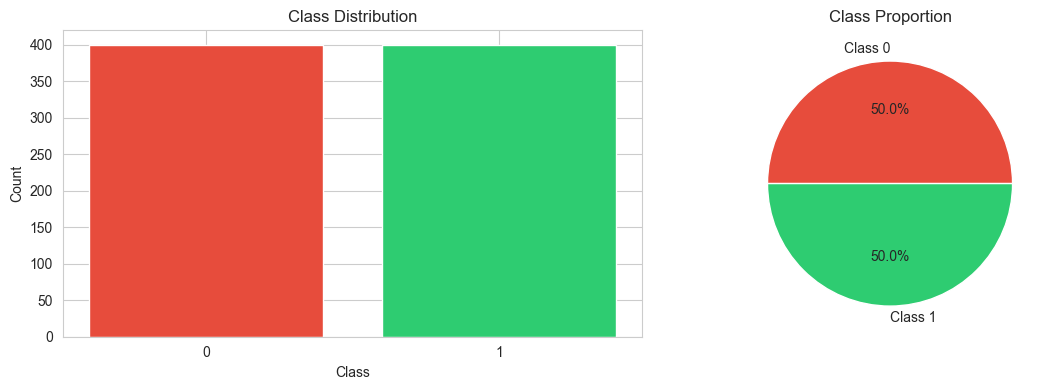


Borderline-SMOTE Model Performance:
----------------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
AUC-ROC:   1.0000

Probability Distribution:
Extreme (<0.1 or >0.9): 100.0%
Middle (0.2-0.8):       0.0%


In [7]:
print("="*60)
print("Borderline-SMOTE")
print("="*60)
print("\nFocuses on generating synthetic samples near the decision boundary")

# Apply Borderline-SMOTE
borderline_smote = BorderlineSMOTE(random_state=42, k_neighbors=5, kind='borderline-1')
X_borderline, y_borderline = borderline_smote.fit_resample(X_train, y_train)

print(f"\nBorderline-SMOTE resampled set size: {len(X_borderline)}")

# Analyze distribution
borderline_dist = analyze_class_distribution(y_borderline, "Borderline-SMOTE Distribution")

# Train and evaluate
borderline_metrics, borderline_proba, borderline_cm = train_and_evaluate(
    X_borderline, y_borderline, X_test, y_test, "Borderline-SMOTE Model"
)

## Method 3: ADASYN (Adaptive Synthetic Sampling)

ADASYN - Adaptive Synthetic Sampling

Generates more synthetic samples for harder-to-learn minority instances

ADASYN resampled set size: 800

ADASYN Distribution:
----------------------------------------
Class 0:   400 samples ( 50.0%)
Class 1:   400 samples ( 50.0%)

Imbalance ratio: 1.00:1
✅ Classes are relatively balanced


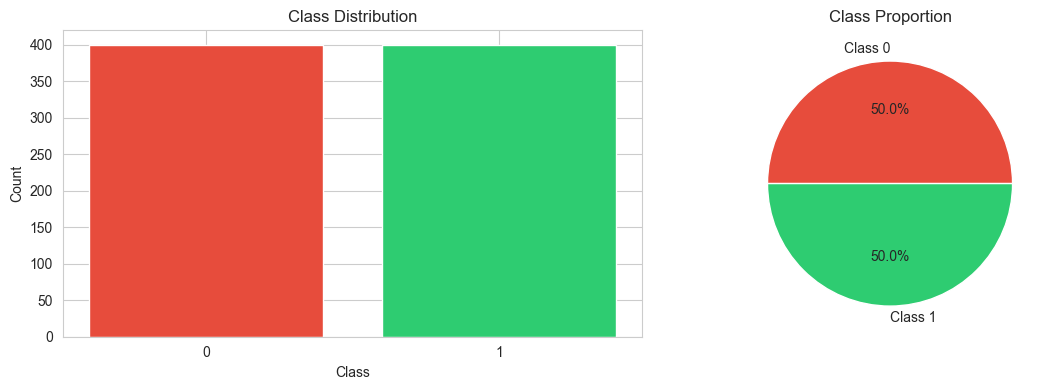


ADASYN Model Performance:
----------------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
AUC-ROC:   1.0000

Probability Distribution:
Extreme (<0.1 or >0.9): 100.0%
Middle (0.2-0.8):       0.0%


In [8]:
print("="*60)
print("ADASYN - Adaptive Synthetic Sampling")
print("="*60)
print("\nGenerates more synthetic samples for harder-to-learn minority instances")

try:
    # Apply ADASYN
    adasyn = ADASYN(random_state=42, n_neighbors=5)
    X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)
    
    print(f"\nADASYN resampled set size: {len(X_adasyn)}")
    
    # Analyze distribution
    adasyn_dist = analyze_class_distribution(y_adasyn, "ADASYN Distribution")
    
    # Train and evaluate
    adasyn_metrics, adasyn_proba, adasyn_cm = train_and_evaluate(
        X_adasyn, y_adasyn, X_test, y_test, "ADASYN Model"
    )
except Exception as e:
    print(f"ADASYN failed: {e}")
    print("This can happen when the minority class is too small")
    adasyn_metrics = None

## Method 4: SMOTE-ENN (Combined Over and Under Sampling)

SMOTE-ENN

Combines SMOTE with Edited Nearest Neighbors for cleaning

Original training set size: 800
SMOTE-ENN resampled set size: 183
Note: SMOTE-ENN may produce smaller dataset due to cleaning

SMOTE-ENN Distribution:
----------------------------------------
Class 0:    70 samples ( 38.3%)
Class 1:   113 samples ( 61.7%)

Imbalance ratio: 0.62:1
✅ Classes are relatively balanced


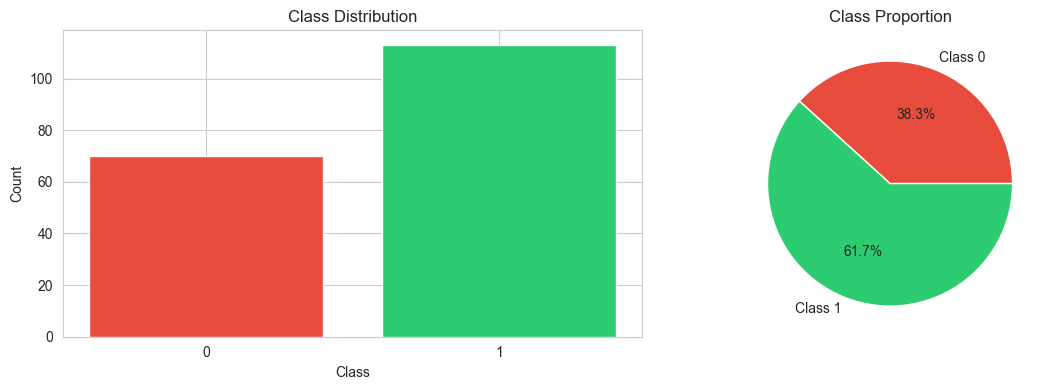


SMOTE-ENN Model Performance:
----------------------------------------
Accuracy:  0.9950
Precision: 1.0000
Recall:    0.9900
F1-Score:  0.9950
AUC-ROC:   0.9950

Probability Distribution:
Extreme (<0.1 or >0.9): 100.0%
Middle (0.2-0.8):       0.0%


In [9]:
print("="*60)
print("SMOTE-ENN")
print("="*60)
print("\nCombines SMOTE with Edited Nearest Neighbors for cleaning")

# Apply SMOTE-ENN
smote_enn = SMOTEENN(random_state=42)
X_smote_enn, y_smote_enn = smote_enn.fit_resample(X_train, y_train)

print(f"\nOriginal training set size: {len(X_train)}")
print(f"SMOTE-ENN resampled set size: {len(X_smote_enn)}")
print("Note: SMOTE-ENN may produce smaller dataset due to cleaning")

# Analyze distribution
smote_enn_dist = analyze_class_distribution(y_smote_enn, "SMOTE-ENN Distribution")

# Train and evaluate
smote_enn_metrics, smote_enn_proba, smote_enn_cm = train_and_evaluate(
    X_smote_enn, y_smote_enn, X_test, y_test, "SMOTE-ENN Model"
)

## Method 5: SMOTE-Tomek

SMOTE-Tomek

Combines SMOTE with Tomek Links removal for boundary cleaning

SMOTE-Tomek resampled set size: 596

SMOTE-Tomek Distribution:
----------------------------------------
Class 0:   298 samples ( 50.0%)
Class 1:   298 samples ( 50.0%)

Imbalance ratio: 1.00:1
✅ Classes are relatively balanced


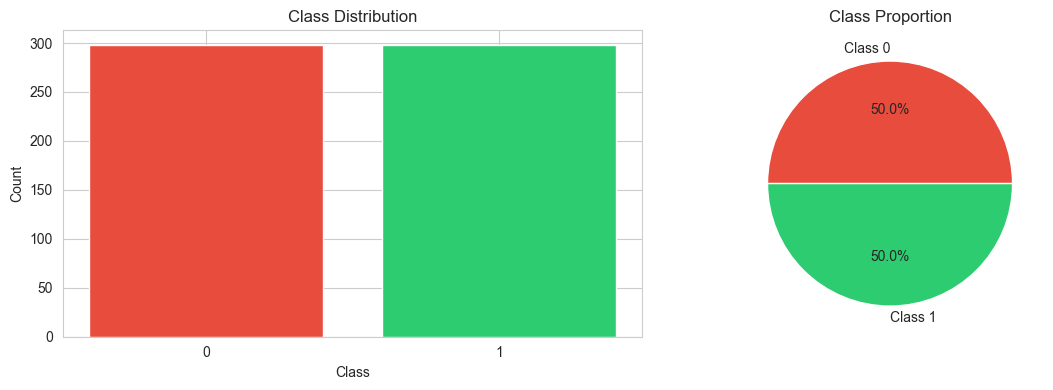


SMOTE-Tomek Model Performance:
----------------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
AUC-ROC:   1.0000

Probability Distribution:
Extreme (<0.1 or >0.9): 100.0%
Middle (0.2-0.8):       0.0%


In [10]:
print("="*60)
print("SMOTE-Tomek")
print("="*60)
print("\nCombines SMOTE with Tomek Links removal for boundary cleaning")

# Apply SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_smote_tomek, y_smote_tomek = smote_tomek.fit_resample(X_train, y_train)

print(f"\nSMOTE-Tomek resampled set size: {len(X_smote_tomek)}")

# Analyze distribution
smote_tomek_dist = analyze_class_distribution(y_smote_tomek, "SMOTE-Tomek Distribution")

# Train and evaluate
smote_tomek_metrics, smote_tomek_proba, smote_tomek_cm = train_and_evaluate(
    X_smote_tomek, y_smote_tomek, X_test, y_test, "SMOTE-Tomek Model"
)

## Method 6: Class Weight Balancing

In [11]:
print("="*60)
print("Class Weight Balancing")
print("="*60)
print("\nAdjusts sample weights instead of creating synthetic samples")

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
weight_dict = dict(zip(classes, class_weights))

print(f"\nClass weights: {weight_dict}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train with class weights
weighted_model = xgb.XGBClassifier(
    max_depth=4,
    n_estimators=100,
    random_state=42,
    scale_pos_weight=class_weights[1]/class_weights[0],  # Ratio for positive class
    use_label_encoder=False,
    eval_metric='logloss'
)

weighted_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_weighted = weighted_model.predict(X_test_scaled)
y_proba_weighted = weighted_model.predict_proba(X_test_scaled)[:, 1]

weighted_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_weighted),
    'precision': precision_score(y_test, y_pred_weighted),
    'recall': recall_score(y_test, y_pred_weighted),
    'f1': f1_score(y_test, y_pred_weighted),
    'auc': roc_auc_score(y_test, y_proba_weighted)
}

print(f"\nClass Weight Model Performance:")
print("-" * 40)
for metric, value in weighted_metrics.items():
    print(f"{metric.capitalize():10}: {value:.4f}")

Class Weight Balancing

Adjusts sample weights instead of creating synthetic samples

Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}

Class Weight Model Performance:
----------------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1        : 1.0000
Auc       : 1.0000


## Compare All Methods

In [12]:
# Collect all results
results = {
    'Baseline': baseline_metrics,
    'SMOTE': smote_metrics,
    'Borderline-SMOTE': borderline_metrics,
    'SMOTE-ENN': smote_enn_metrics,
    'SMOTE-Tomek': smote_tomek_metrics,
    'Class Weights': weighted_metrics
}

if adasyn_metrics is not None:
    results['ADASYN'] = adasyn_metrics

# Create comparison DataFrame
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4)

print("\n" + "="*80)
print("COMPARISON OF ALL BALANCING METHODS")
print("="*80)
print(comparison_df.to_string())

# Find best method for each metric
print("\n" + "="*80)
print("BEST METHOD FOR EACH METRIC")
print("="*80)

for metric in comparison_df.columns:
    best_method = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"{metric:10}: {best_method:20} ({best_value:.4f})")


COMPARISON OF ALL BALANCING METHODS
                  accuracy  precision  recall     f1    auc
Baseline             1.000        1.0    1.00  1.000  1.000
SMOTE                1.000        1.0    1.00  1.000  1.000
Borderline-SMOTE     1.000        1.0    1.00  1.000  1.000
SMOTE-ENN            0.995        1.0    0.99  0.995  0.995
SMOTE-Tomek          1.000        1.0    1.00  1.000  1.000
Class Weights        1.000        1.0    1.00  1.000  1.000
ADASYN               1.000        1.0    1.00  1.000  1.000

BEST METHOD FOR EACH METRIC
accuracy  : Baseline             (1.0000)
precision : Baseline             (1.0000)
recall    : Baseline             (1.0000)
f1        : Baseline             (1.0000)
auc       : Baseline             (1.0000)


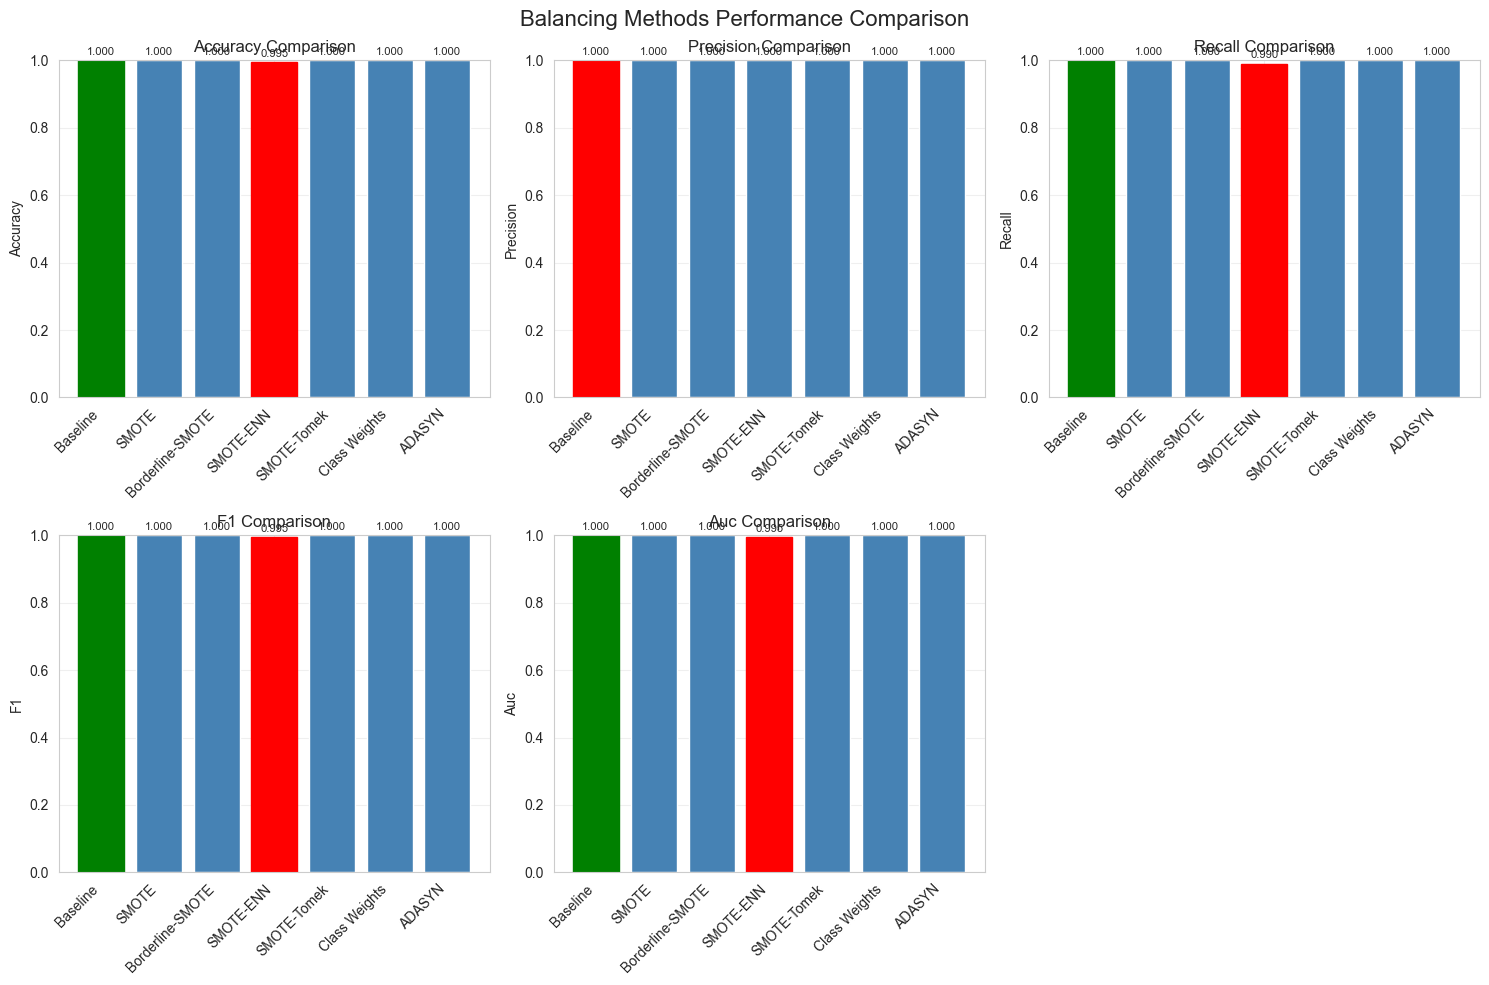

In [13]:
# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'auc']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    values = comparison_df[metric].values
    methods = comparison_df.index
    
    bars = ax.bar(range(len(methods)), values, color='steelblue')
    
    # Highlight best
    best_idx = np.argmax(values)
    bars[best_idx].set_color('green')
    
    # Highlight worst
    worst_idx = np.argmin(values)
    bars[worst_idx].set_color('red')
    
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=45, ha='right')
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f'{metric.capitalize()} Comparison')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(values):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# Remove extra subplot
axes[-1].remove()

plt.suptitle('Balancing Methods Performance Comparison', fontsize=16)
plt.tight_layout()
plt.show()

## Probability Distribution Analysis

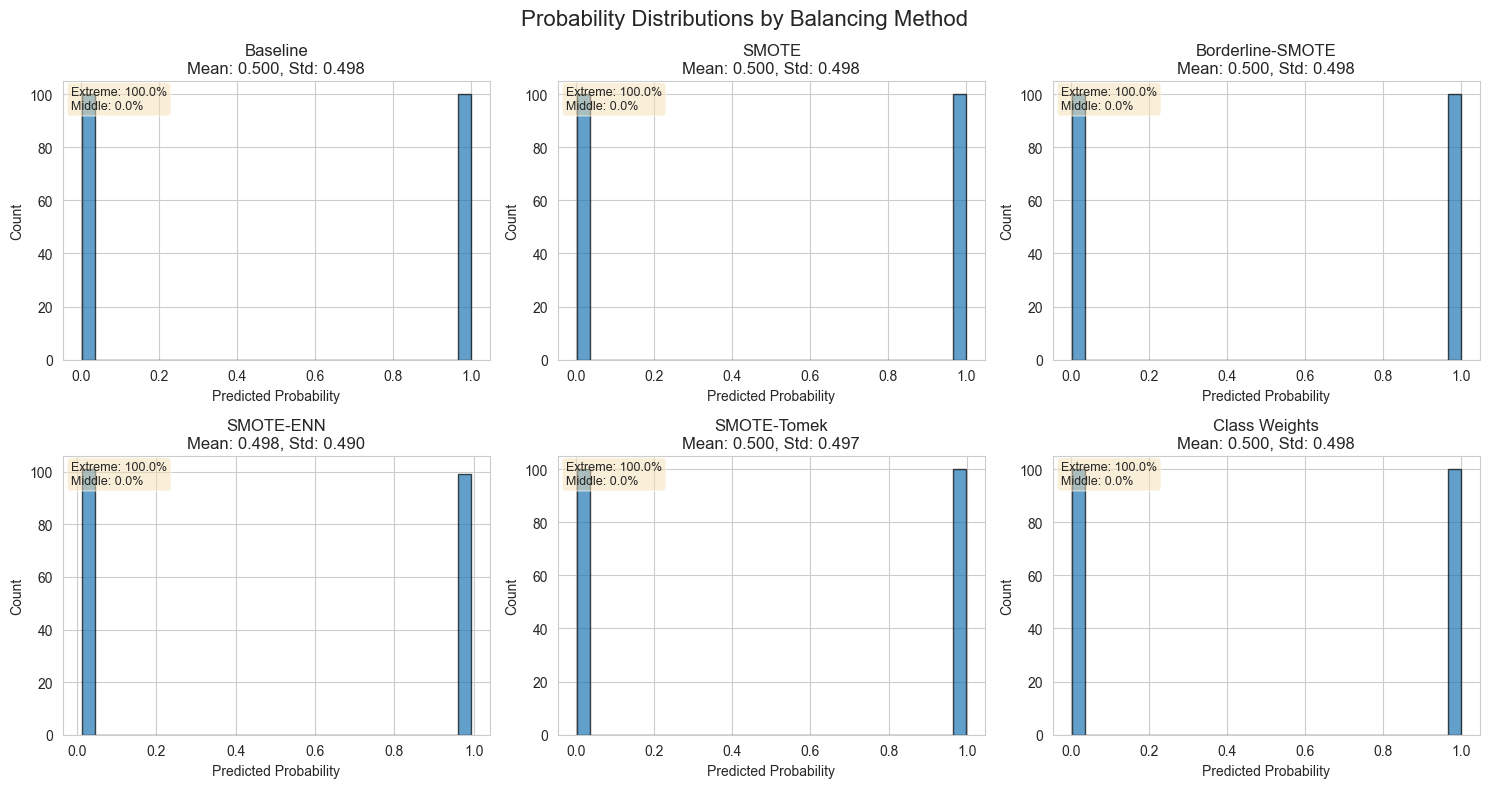

In [14]:
# Analyze probability distributions
prob_distributions = {
    'Baseline': baseline_proba,
    'SMOTE': smote_proba,
    'Borderline-SMOTE': borderline_proba,
    'SMOTE-ENN': smote_enn_proba,
    'SMOTE-Tomek': smote_tomek_proba,
    'Class Weights': y_proba_weighted
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (name, proba) in enumerate(prob_distributions.items()):
    if idx < 6:
        ax = axes[idx]
        ax.hist(proba, bins=30, alpha=0.7, edgecolor='black')
        ax.set_xlabel('Predicted Probability')
        ax.set_ylabel('Count')
        ax.set_title(f'{name}\nMean: {np.mean(proba):.3f}, Std: {np.std(proba):.3f}')
        
        # Add statistics
        extreme = np.sum((proba < 0.1) | (proba > 0.9))
        middle = np.sum((proba >= 0.2) & (proba <= 0.8))
        
        stats_text = f'Extreme: {extreme/len(proba)*100:.1f}%\nMiddle: {middle/len(proba)*100:.1f}%'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                verticalalignment='top', fontsize=9, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Probability Distributions by Balancing Method', fontsize=16)
plt.tight_layout()
plt.show()

## Optimal Threshold Selection

In [15]:
def find_optimal_threshold(y_true, y_proba):
    """Find optimal threshold for classification"""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    
    # Calculate F1 scores
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    # Find optimal threshold
    optimal_idx = np.argmax(f1_scores[:-1])  # Exclude last element
    optimal_threshold = thresholds[optimal_idx]
    optimal_f1 = f1_scores[optimal_idx]
    
    return optimal_threshold, optimal_f1

print("\n" + "="*80)
print("OPTIMAL THRESHOLDS FOR EACH METHOD")
print("="*80)

for name, proba in prob_distributions.items():
    opt_threshold, opt_f1 = find_optimal_threshold(y_test, proba)
    
    # Evaluate with optimal threshold
    y_pred_optimal = (proba >= opt_threshold).astype(int)
    f1_optimal = f1_score(y_test, y_pred_optimal)
    
    print(f"\n{name}:")
    print(f"  Optimal threshold: {opt_threshold:.3f}")
    print(f"  F1 at 0.5 threshold: {results[name]['f1']:.4f}")
    print(f"  F1 at optimal threshold: {f1_optimal:.4f}")
    print(f"  Improvement: {(f1_optimal - results[name]['f1']):.4f}")


OPTIMAL THRESHOLDS FOR EACH METHOD

Baseline:
  Optimal threshold: 0.998
  F1 at 0.5 threshold: 1.0000
  F1 at optimal threshold: 1.0000
  Improvement: 0.0000

SMOTE:
  Optimal threshold: 0.998
  F1 at 0.5 threshold: 1.0000
  F1 at optimal threshold: 1.0000
  Improvement: 0.0000

Borderline-SMOTE:
  Optimal threshold: 0.998
  F1 at 0.5 threshold: 1.0000
  F1 at optimal threshold: 1.0000
  Improvement: 0.0000

SMOTE-ENN:
  Optimal threshold: 0.992
  F1 at 0.5 threshold: 0.9950
  F1 at optimal threshold: 0.9950
  Improvement: 0.0000

SMOTE-Tomek:
  Optimal threshold: 0.997
  F1 at 0.5 threshold: 1.0000
  F1 at optimal threshold: 1.0000
  Improvement: 0.0000

Class Weights:
  Optimal threshold: 0.998
  F1 at 0.5 threshold: 1.0000
  F1 at optimal threshold: 1.0000
  Improvement: 0.0000


## Best Strategy Selection

In [16]:
# Calculate composite score for each method
print("\n" + "="*80)
print("BEST STRATEGY SELECTION")
print("="*80)

# Weight different metrics
weights = {
    'f1': 0.3,
    'recall': 0.2,
    'precision': 0.2,
    'auc': 0.3
}

scores = {}
for method, metrics in results.items():
    score = sum(metrics[metric] * weight for metric, weight in weights.items())
    scores[method] = score

# Sort by score
sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)

print("\nComposite Scores (weighted combination of metrics):")
print("-" * 40)
for rank, (method, score) in enumerate(sorted_scores, 1):
    print(f"{rank}. {method:20} Score: {score:.4f}")

best_method = sorted_scores[0][0]
print(f"\n🏆 Best Method: {best_method}")
print(f"   F1-Score: {results[best_method]['f1']:.4f}")
print(f"   Recall: {results[best_method]['recall']:.4f}")
print(f"   AUC: {results[best_method]['auc']:.4f}")


BEST STRATEGY SELECTION

Composite Scores (weighted combination of metrics):
----------------------------------------
1. Baseline             Score: 1.0000
2. SMOTE                Score: 1.0000
3. Borderline-SMOTE     Score: 1.0000
4. SMOTE-Tomek          Score: 1.0000
5. Class Weights        Score: 1.0000
6. ADASYN               Score: 1.0000
7. SMOTE-ENN            Score: 0.9950

🏆 Best Method: Baseline
   F1-Score: 1.0000
   Recall: 1.0000
   AUC: 1.0000
